# Notebook 02: Outlier cleaning

Loads the EDA output, applies selected outlier cleaning, and writes intermediate data.

**Notebook run order**

| Step | Notebook | Purpose | Output |
|---|---|---|---|
| 1 | [01-EDA.ipynb](01-EDA.ipynb) | EDA and baseline profiling | `data/01-EDA.csv` |
| 2 | **[02-outlier-cleaning.ipynb](02-outlier-cleaning.ipynb)** | **Outlier strategy evaluation and cleaning** | **`data/02-outlier-cleaning.csv`** |
| 3 | [03-feature-transformations.ipynb](03-feature-transformations.ipynb) | Per-feature transform scans and apply | `data/03-feature-transformations.csv` |
| 4 | [04-interaction-features.ipynb](04-interaction-features.ipynb) | Interaction scans and feature adds | `data/04-interaction-features.csv` |
| 5 | [05-p_censoring.ipynb](05-p_censoring.ipynb) | OOF censoring probability feature | `data/x-final.csv` |

## 1. Notebook set-up

In [1]:
import contextlib
import io
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

sys.path.insert(0, str(Path.cwd().resolve().parent / 'src'))
import featurely as fl

from config import DATA_DIR, OUTLIER_METHOD, OUTLIER_THRESHOLD

## 2. Data loading

In [2]:
in_path = DATA_DIR / '01-EDA.csv'

if not in_path.exists():
    raise FileNotFoundError(
        (f'Missing required input file: {in_path}. Run 01-EDA.ipynb ' +
         'first to generate data/01-EDA.csv.')
    )

housing_df = pd.read_csv(in_path)
features = [c for c in housing_df.columns if c != 'MedHouseVal']
print(f'Loaded: {in_path}')

Loaded: /workspaces/featurely/data/01-EDA.csv


## 3. Method comparison

In [3]:
methods = ['ignore', 'clip', 'impute', 'transform']
cv_results = {}

for method in methods:

    df = housing_df.copy()

    with contextlib.redirect_stdout(io.StringIO()):
        if method == 'clip':
            df = fl.clip_outliers(df, features)

        elif method == 'impute':
            df = fl.impute_outliers_with_knn(df, features, n_neighbors=7)

        elif method == 'transform':
            df = fl.transform_outliers(df, features)

    scores = cross_val_score(
        LinearRegression(),
        df.drop('MedHouseVal', axis=1),
        df['MedHouseVal'],
        cv=10,
        scoring='r2'
    )

    cv_results[method] = scores
    print(f'{method:>10}: mean R2 = {scores.mean():.4f} ± {scores.std():.4f}')

f_stat, p_value = f_oneway(*cv_results.values())
print(f'\nANOVA: F={f_stat:.4f}, p={p_value:.4f}')  

    ignore: mean R2 = 0.5110 ± 0.0593
      clip: mean R2 = 0.5697 ± 0.0563
    impute: mean R2 = 0.4526 ± 0.0771
 transform: mean R2 = 0.5162 ± 0.0709

ANOVA: F=4.6755, p=0.0074


## 4. Clean outliers

In [4]:
if OUTLIER_METHOD == 'clip':
    housing_df = fl.clip_outliers(housing_df, features, threshold=OUTLIER_THRESHOLD)

elif OUTLIER_METHOD == 'impute':
    housing_df = fl.impute_outliers_with_knn(
        housing_df, features, n_neighbors=7, threshold=OUTLIER_THRESHOLD
    )

elif OUTLIER_METHOD == 'transform':
    housing_df = fl.transform_outliers(housing_df, features)

else:
    print('Ignoring outliers; no changes made.')

MedInc: Outliers clipped to [-2.34, 9.65]
HouseAge: Outliers clipped to [-24.75, 79.75]
AveRooms: Outliers clipped to [0.81, 9.68]
AveBedrms: Outliers clipped to [0.80, 1.31]
Population: Outliers clipped to [-1323.50, 3835.50]
AveOccup: Outliers clipped to [0.51, 5.20]
Latitude: Outliers clipped to [25.42, 46.22]
Longitude: Outliers clipped to [-130.33, -109.48]


## 5. Cleaned feature distributions

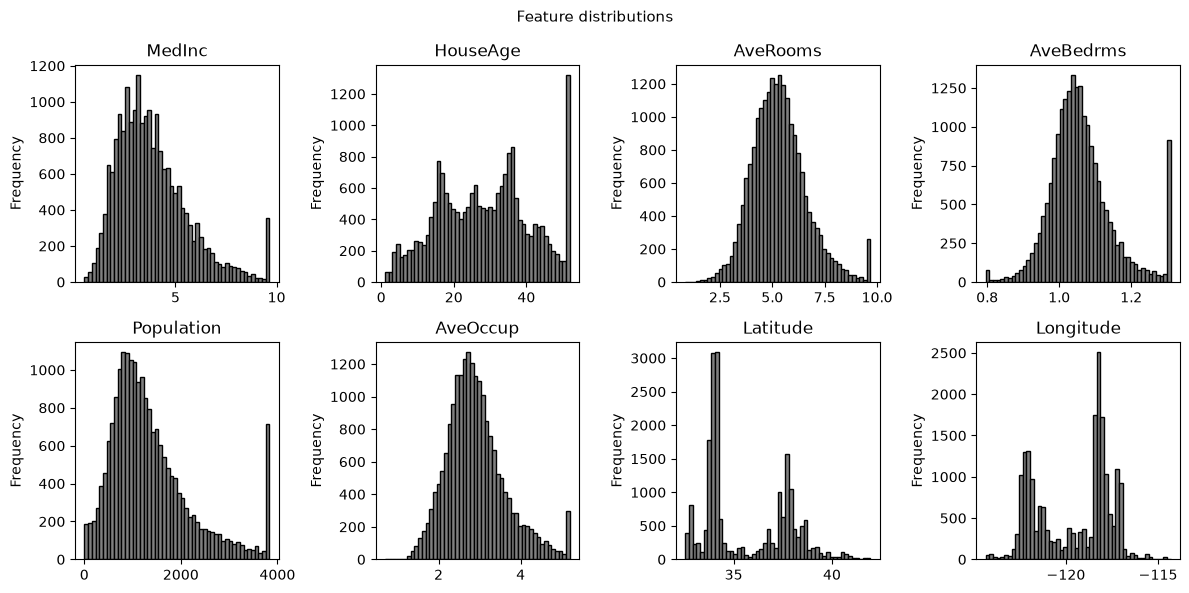

In [5]:
fl.plot_feature_distributions(housing_df)

## 6. Save output

In [6]:
out_path = DATA_DIR / '02-outlier-cleaning.csv'
housing_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: /workspaces/featurely/data/02-outlier-cleaning.csv
